# 014a · AR-MA · Teoría

**Estadística, Detección de Anomalías e Imputación de Series Temporales**
Posgrado en Ingeniería · Área Energía · IER-UNAM

Sesión de **45 min** (teoría). El laboratorio sobre La Ventosa vive en `014b_LaVentosa.py`.
Plan completo: `PLAN-AR-MA.md`.

**Cómo ejecutar.** Celdas virtuales `# %%` (formato jupytext-percent).
- VS Code: `Shift+Enter` por celda.
- Notebook: `jupytext --to ipynb 014a_ARMA_TeoLab.py`.

---
### Cómo usar esta libreta — guía para el instructor

Las celdas tipo **`> Notas para el instructor`** (citas con `>`) son señales pedagógicas:

- **Notas para el instructor** — lo que conviene hacer/decir en ese momento (pizarrón, demostración manual, ritmo).
- **Para discutir con la clase** — preguntas abiertas para detener la ejecución y abrir conversación.
- **Errores comunes** — confusiones recurrentes que conviene anticipar.
- **Pausa pedagógica** — momentos donde no hay que correr la siguiente celda hasta que los alumnos opinen.

Si vas justo de tiempo, salta las pausas pedagógicas pero **no** los puntos de discusión: son los que fijan el aprendizaje.

---

## Apertura · 5 min

> *"Mañana vas a operar un parque eólico en La Ventosa. Tienes 3 meses de viento
> horario. ¿Puedes pronosticar la siguiente hora con esos datos solos?"*

Una serie temporal es la realización de un **proceso estocástico** ordenado en el tiempo.
Modelarla = explicar el valor actual a partir de:

- su **pasado** (componente autorregresivo, AR), y/o
- los **choques aleatorios pasados** (componente de media móvil, MA).

Lugar en el curso: tras EDA y descomposición; antes de SARIMA, espacio-estados y ML.

> **Para discutir con la clase (3 min).**
> - ¿Qué métodos conocen ya para pronosticar series? (probable: regresión, promedios móviles, "ojo experto").
> - Si no tuvieran computadora, ¿qué predecirían para mañana a las 14:00? Anclar la intuición *antes* de mostrar máquinas.
> - ¿Por qué el viento podría ser más predecible "a la siguiente hora" que "a los siete días"?

> **Notas para el instructor.** No abrir la teoría hasta que alguien diga al menos una vez "depende de lo que pasó antes". Esa frase es la entrada natural a AR(p).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

## Helpers — los dos pasos del ciclo Box-Jenkins

Los reusaremos en cada iteración (también en `014b_LaVentosa.py`):
- `mirar()`: identificación (ADF + ACF + PACF).
- `diagnostico()`: validación (residuales + ACF residual + Ljung-Box).

In [2]:
def mirar(serie, nombre, lags=30):
    """Identificación: ADF + ACF + PACF."""
    serie = pd.Series(serie).dropna()

    stat, p, *_ = adfuller(serie, autolag="AIC")
    veredicto = "estacionaria" if p < 0.05 else "NO estacionaria"
    print(f"ADF · {nombre}:  estadístico = {stat:.3f},  p = {p:.4f}  →  {veredicto}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    plot_acf(serie,  lags=lags, ax=axes[0]); axes[0].set_title(f"ACF — {nombre}")
    plot_pacf(serie, lags=lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF — {nombre}")
    plt.tight_layout(); plt.show()


def diagnostico(modelo, nombre, lags=20):
    """Validación: residuales + ACF residual + Ljung-Box."""
    p, d, q = modelo.model.order
    resid = modelo.resid.iloc[max(p, q):]

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    axes[0].plot(resid.values, lw=0.6); axes[0].axhline(0, color="k", lw=0.5)
    axes[0].set_title(f"Residuales — {nombre}")
    plot_acf(resid, lags=lags, ax=axes[1])
    axes[1].set_title("ACF de residuales")
    plt.tight_layout(); plt.show()

    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    print(f"Ljung-Box · {nombre}")
    print(lb.round(4))
    return lb

# Bloque 1 · Teoría (45 min)

## T1 · Estacionariedad · 10 min

**Definición débil (covarianza-estacionaria).** Un proceso $\{y_t\}$ es estacionario
en sentido débil si:

1. $E[y_t] = \mu$ constante en $t$,
2. $\mathrm{Var}(y_t) = \sigma^2$ constante en $t$,
3. $\mathrm{Cov}(y_t, y_{t+k}) = \gamma(k)$ depende solo del rezago $k$, no de $t$.

**Por qué importa.** ARMA solo está bien definido —y los estimadores son
consistentes— sobre un proceso estacionario. Si la serie tiene tendencia o
estacionalidad, los parámetros que estimes no significan nada estable.

**Prueba operativa: ADF (Augmented Dickey-Fuller).**
- $H_0$: existe raíz unitaria → **no** estacionaria.
- $H_1$: estacionaria.
- Regla: $p < 0.05$ → rechazo $H_0$ → trabajable con ARMA.

Si **no** es estacionaria: diferenciar (lleva a ARIMA), restar tendencia,
o restar climatología (lo que haremos en el laboratorio).

> **Notas para el instructor.** Antes de correr el demo, dibujar en pizarrón dos series
> a mano: una que oscila alrededor de un nivel, otra que vaga sin volver. Pedir a los alumnos
> que digan cuál parece "predecible". El concepto de estacionariedad cala mucho mejor
> después de ese ejercicio manual de 90 segundos.

> **Errores comunes que hay que desactivar pronto.**
> 1. Confundir estacionariedad con "no tiene tendencia". La estacionariedad es más estricta:
>    también exige varianza y autocovarianza estables.
> 2. Pensar que el ADF detecta estacionalidad. **No lo hace.** Detecta raíces unitarias.
>    Una serie con ciclo diario perfecto puede pasar el ADF sin problema (lo veremos en el lab).

### Demo · estacionario vs no estacionario

Comparamos dos series del mismo largo: un AR(1) estable vs una caminata aleatoria
(raíz unitaria). Visualmente la diferencia salta; ADF lo confirma.

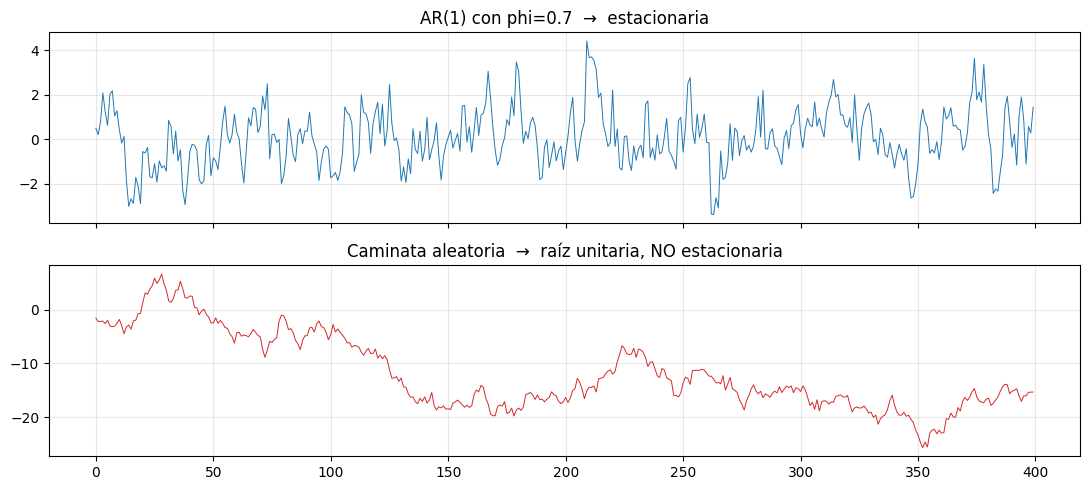

ADF · AR(1) estable       p = 0.0000  →  estacionaria
ADF · caminata            p = 0.3937  →  NO estacionaria


In [3]:
N = 400
estacionaria = pd.Series(ArmaProcess(ar=[1, -0.7], ma=[1]).generate_sample(N))
caminata     = pd.Series(np.random.randn(N).cumsum())

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
estacionaria.plot(ax=axes[0], lw=0.7, color="C0")
axes[0].set_title("AR(1) con phi=0.7  →  estacionaria")
caminata.plot(ax=axes[1], lw=0.7, color="C3")
axes[1].set_title("Caminata aleatoria  →  raíz unitaria, NO estacionaria")
plt.tight_layout(); plt.show()

for nombre, s in [("AR(1) estable", estacionaria), ("caminata", caminata)]:
    stat, p, *_ = adfuller(s, autolag="AIC")
    print(f"ADF · {nombre:18s}  p = {p:.4f}  →  {'estacionaria' if p < 0.05 else 'NO estacionaria'}")

El AR(1) oscila alrededor de un nivel; la caminata vaga sin volver. **ADF lo certifica.**
Esa es la primera puerta antes de tocar `ARIMA(...)`.

> **Para discutir con la clase.**
> - Si forzáramos un AR(1) sobre la caminata aleatoria, ¿qué $\phi$ esperarían? (Respuesta:
>   muy cercano a 1, pero el modelo estaría **mal especificado** y los IC del pronóstico
>   serían engañosamente estrechos).
> - ¿Conocen series reales que se parezcan a la caminata? (Pistas: precios bursátiles, niveles
>   piezométricos sin recarga, posición de un objeto sometido solo a ruido).
> - ¿Por qué el ADF se llama *aumentado*? (Versión simple Dickey-Fuller agrega lags de la
>   diferencia para absorber autocorrelación de orden mayor a 1).

## T2 · Modelo AR(p) · 10 min

**Ecuación.**
$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t,
\qquad \varepsilon_t \sim \mathrm{WN}(0, \sigma^2)
$$

**Intuición física: *inercia*.** El sistema "recuerda" su pasado reciente.
Ejemplo: el nivel del lago Hurón hoy depende del de ayer porque el agua tarda
en entrar/salir. Cualquier desviación se relaja exponencialmente al equilibrio.

**Condición de estacionariedad.** Las raíces de
$1 - \phi_1 z - \cdots - \phi_p z^p = 0$ deben caer **fuera** del círculo unitario.
Para AR(1): $|\phi| < 1$.

**Firma diagnóstica:**

| | ACF | PACF |
|---|---|---|
| AR(p) | decae geométricamente | **corta** después del lag $p$ |

La PACF "corta" porque mide correlación parcial: una vez que controlas los lags
$1, \dots, p$, el resto del pasado ya no aporta nada nuevo.

> **Para discutir con la clase.**
> - Den **tres ejemplos físicos** de inercia que podrían modelarse como AR. Pistas: térmicos
>   (una habitación tarda en cambiar de temperatura), hidráulicos (lago, embalse), económicos
>   (inventarios). Forzar a que los ejemplos vengan de su área.
> - ¿Qué pasa con $\phi = 1$? (Caminata aleatoria — caso límite, justo lo que vimos antes).
> - ¿Qué pasa con $\phi$ negativo? (La serie alterna de signo cada paso — describe sistemas
>   con sobrerreacción/oscilación).
> - ¿Por qué $\phi > 1$ es problema? (Explosivo: cada desviación crece sin acotar).

### Demo · AR(1) sintético

Generamos $y_t = 0.8 \, y_{t-1} + \varepsilon_t$ con $N=500$ y miramos su firma.

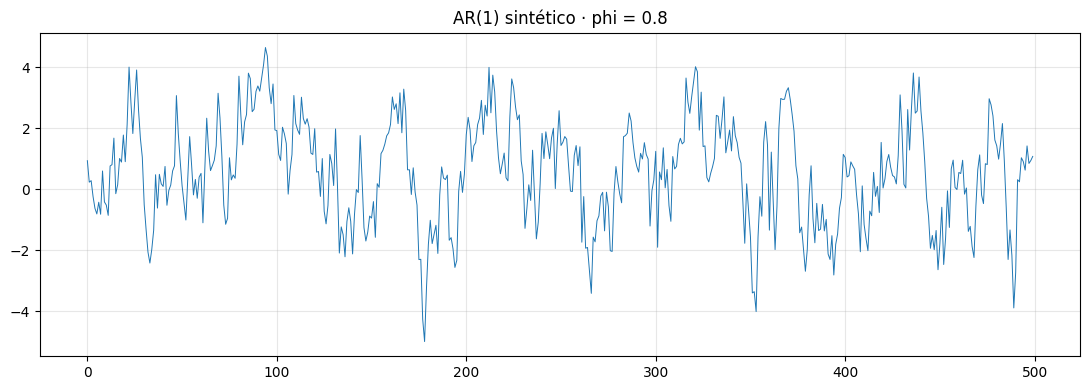

ADF · AR(1):  estadístico = -7.331,  p = 0.0000  →  estacionaria


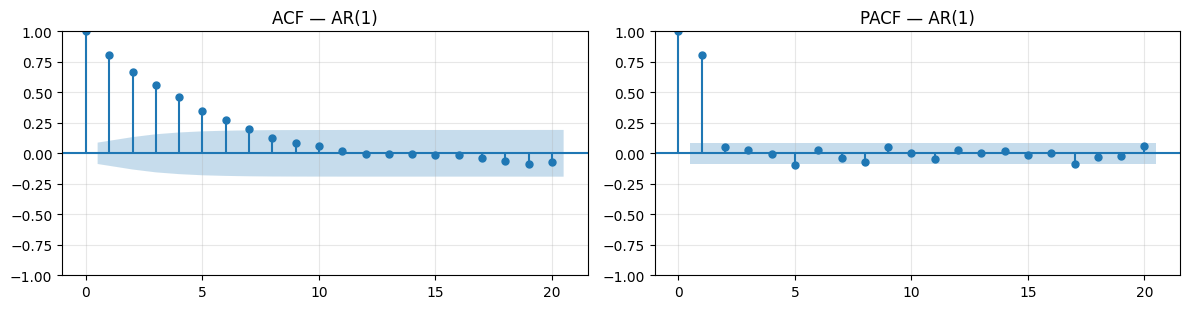

In [4]:
phi_true = 0.8
y_ar1 = pd.Series(ArmaProcess(ar=[1, -phi_true], ma=[1]).generate_sample(500))

y_ar1.plot(lw=0.7, color="C0", title=f"AR(1) sintético · phi = {phi_true}")
plt.tight_layout(); plt.show()

mirar(y_ar1, "AR(1)", lags=20)

**Lo que tenemos que ver.** ACF que decae suave; PACF con un único pico claro en lag 1
y todo lo demás dentro de banda. Esa es la firma textbook del AR(1). Verifiquemos
que el ajuste recupera el coeficiente:

In [5]:
ar1_fit = ARIMA(y_ar1, order=(1, 0, 0)).fit()
print(f"AR(1):  phi verdadero = {phi_true},  estimado = {ar1_fit.params['ar.L1']:.3f}")

AR(1):  phi verdadero = 0.8,  estimado = 0.803


Con $N=500$ recuperamos $\phi$ a una o dos centésimas. **El procedimiento funciona.**

> **Notas para el instructor.** Si alguien pregunta por la convención `ar=[1, -phi]` de
> statsmodels: viene de escribir el AR(1) como $(1 - \phi L) y_t = \varepsilon_t$, donde
> $L$ es el operador de rezago. statsmodels recibe los coeficientes del polinomio
> $1 - \phi L$, por eso `[1, -phi]`. Es la pregunta-trampa típica del primer encuentro.

## T3 · Modelo MA(q) · 10 min

**Ecuación.**
$$
y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2}
      + \cdots + \theta_q \varepsilon_{t-q}
$$

**Intuición física: *eco de choques*.** Hubo una sorpresa hace 1, 2, ..., $q$ pasos
y todavía se siente. Pasados $q$ pasos, el efecto se extingue por completo.

**Estacionariedad.** Un MA finito siempre es estacionario (es combinación lineal
acotada de ruido blanco). La condición análoga es la **invertibilidad**: raíces de
$1 + \theta_1 z + \cdots + \theta_q z^q = 0$ fuera del círculo unitario, para que
el MA tenga una representación AR(∞) equivalente.

**Firma diagnóstica (espejo del AR):**

| | ACF | PACF |
|---|---|---|
| MA(q) | **corta** después del lag $q$ | decae geométricamente |

> **Errores comunes.**
> 1. Confundir el MA(q) con la **media móvil descriptiva** (rolling mean) que se usa
>    para suavizar series. **No son lo mismo.** El MA(q) modela ecos de innovaciones
>    aleatorias; el rolling mean es un filtro determinista.
> 2. Olvidar la invertibilidad. Si $|\theta| \geq 1$ en MA(1), el modelo "ajusta" pero
>    los residuales no son únicos y la representación no es interpretable.

> **Para discutir con la clase.**
> - Den **dos ejemplos de "eco de choques"** en su área. Pistas: shocks de demanda en
>   inventarios, anuncios de política monetaria que se digieren en 2-3 trimestres,
>   error de medición de un sensor que arrastra un offset durante varias muestras.

### Demo · MA(1) sintético

Generamos $y_t = \varepsilon_t + 0.8 \, \varepsilon_{t-1}$ y comparamos con el AR(1) anterior.

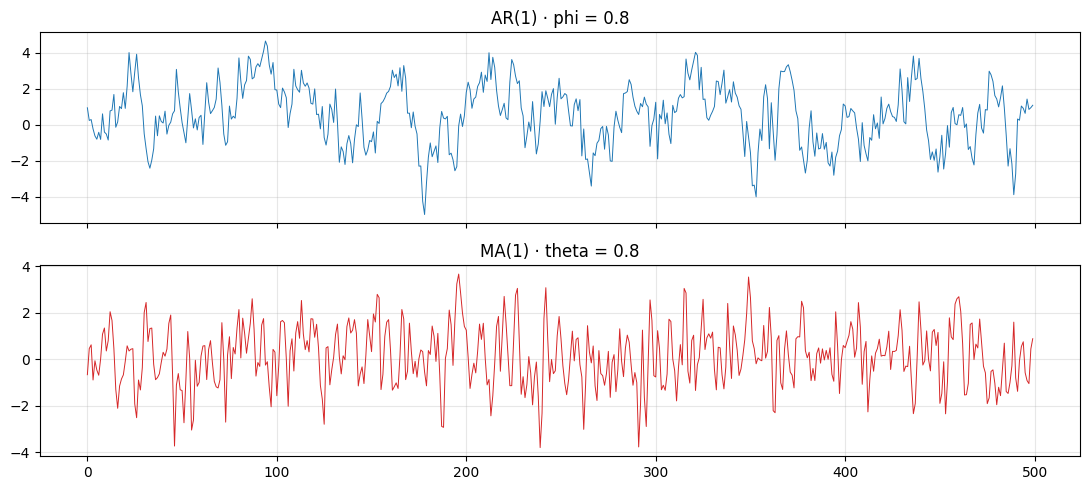

In [6]:
theta_true = 0.8
y_ma1 = pd.Series(ArmaProcess(ar=[1], ma=[1, theta_true]).generate_sample(500))

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
y_ar1.plot(ax=axes[0], lw=0.7, color="C0")
axes[0].set_title(f"AR(1) · phi = {phi_true}")
y_ma1.plot(ax=axes[1], lw=0.7, color="C3")
axes[1].set_title(f"MA(1) · theta = {theta_true}")
plt.tight_layout(); plt.show()

**Mira las dos series unos segundos.** A ojo son casi idénticas: la misma "textura"
de rachas. La diferencia entre AR y MA **no es visual** — es estructural, y se ve
en ACF/PACF. Por eso necesitamos esos dos diagnósticos.

> **Pausa pedagógica (60 s).** Antes de correr la siguiente celda, preguntar al grupo:
> "¿Cuál creen que es AR y cuál MA mirando solo las series?" Recoger las respuestas
> a mano alzada. La división estará cerca de 50/50 — esa **es la lección**: el ojo
> no basta, los diagnósticos sí.

ADF · MA(1):  estadístico = -6.051,  p = 0.0000  →  estacionaria


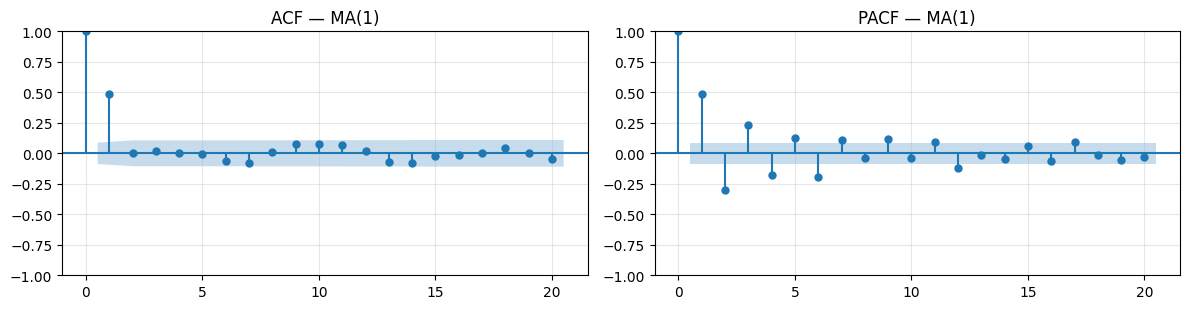

In [7]:
mirar(y_ma1, "MA(1)", lags=20)

In [8]:
ma1_fit = ARIMA(y_ma1, order=(0, 0, 1)).fit()
print(f"MA(1):  theta verdadero = {theta_true},  estimado = {ma1_fit.params['ma.L1']:.3f}")

MA(1):  theta verdadero = 0.8,  estimado = 0.884


**La firma es espejo de la del AR(1):** ACF que **corta** después de lag 1,
PACF que decae. Si memorizas esta tabla, ya tienes el 80% de la identificación:

| | ACF | PACF |
|---|---|---|
| AR(p) | decae | corta en lag $p$ |
| MA(q) | corta en lag $q$ | decae |
| ARMA(p,q) | decae | decae |

> **Para discutir con la clase.**
> - Si una serie real tiene ACF que decae **y** PACF que decae, ¿qué orden propondrían?
>   (Respuesta: ARMA(p,q) con ambos $> 0$. La fila más difícil de la tabla, porque ya
>   no es trivial elegir $p$ y $q$ — ahí es donde Box-Jenkins se vuelve iterativo).
> - ¿Por qué la PACF de un MA decae en lugar de cortar? (Pista: un MA(q) es equivalente
>   a un AR(∞), y un AR de orden infinito tiene PACF que decae).

## T4 · ARMA(p,q) y metodología Box-Jenkins · 10 min

**Ecuación combinada.**
$$
y_t = c + \sum_{i=1}^{p} \phi_i y_{t-i}
        + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$

**Por qué combinar.** Los procesos reales rara vez son AR puro o MA puro.
ARMA da **parsimonia**: a veces ARMA(1,1) ajusta lo mismo que AR(5) o MA(7),
con muchos menos parámetros.

**Metodología Box-Jenkins (1970)** — el corazón operativo de toda la sesión:

1. **Identificar.** ADF → ACF → PACF → hipótesis de orden $(p, q)$.
2. **Estimar.** Ajustar el modelo (máxima verosimilitud).
3. **Diagnosticar.** ¿Los residuales son ruido blanco?
   - ACF residual dentro de bandas.
   - **Ljung-Box**: $H_0$ "los residuales no están autocorrelacionados".
     $p > 0.05$ → no se rechaza → modelo adecuado.
4. **Si falla:** subir $p$ o $q$ y volver a 2.
5. **Si nunca pasa:** el problema **no es de orden** — falta estacionalidad,
   exógenas, o no linealidad.

**Criterios de selección.**
- **AIC, BIC**: comparar modelos. Menor es mejor (pero no es el único criterio).
- **Significancia de coeficientes**: si el último $\phi$ o $\theta$ no es
  significativo, sobreajustaste.
- **Parsimonia**: a igualdad de diagnóstico, gana el modelo con menos parámetros.

Con esto cerramos la teoría. El laboratorio sobre La Ventosa (`014b_LaVentosa.py`)
vive el ciclo completo sobre datos reales.

> **Notas para el instructor.** Dibujar el ciclo Box-Jenkins en el pizarrón como un
> diagrama de flujo: caja → caja → rombo de decisión → flecha de retorno. Es la
> única figura **que el alumno debe poder dibujar de memoria** al final de la sesión.
> Si no la puede dibujar, no entendió el método.

> **Para discutir con la clase.**
> - **AIC vs BIC**: cuando dan resultados distintos, ¿cuál usar? (BIC penaliza más fuerte
>   los parámetros — es asintóticamente consistente para selección de modelo verdadero;
>   AIC es mejor para predicción. Para Box-Jenkins en producción, BIC tiende a elegir
>   modelos más parsimoniosos).
> - ¿Qué pasaría si Ljung-Box rechaza pero AIC es bajo? (Modelo mal especificado pero
>   que ajustó bien la varianza. El AIC puede mentir si los residuales no son blancos:
>   por eso el orden es **primero diagnóstico, luego AIC**, no al revés).
> - ¿Hay un "ARMA óptimo"? (No. Hay un ARMA *adecuado* — uno cuyos residuales son
>   indistinguibles de ruido blanco. Box-Jenkins busca *adecuación*, no optimalidad).

# Cierre de la teoría

El laboratorio (`014b_LaVentosa.py`) aplica esta metodología a viento horario en
La Ventosa, Oaxaca: identificación, iteración Box-Jenkins, pronóstico, y la
frontera de aplicabilidad de ARMA (cuando aparece estacionalidad).

## Lecturas

- Box, Jenkins, Reinsel, Ljung (2015). *Time Series Analysis: Forecasting and Control*
  (5th ed.). Caps. 3–4.
- Cryer & Chan (2008). *Time Series Analysis: With Applications in R*. Caps. 4–6.
- Hyndman & Athanasopoulos. *Forecasting: Principles and Practice*.
  https://otexts.com/fpp3/ (cap. 9).